<img src="https://raw.githubusercontent.com/drdave-teaching/OPIM5509-notebooks/main/_banners/opim5509_banner.svg" width="100%" alt="OPIM 5509 banner"/>

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/drdave-teaching/OPIM5509Files/blob/main/OPIM5509_Module5_Files/notebooks/Who_Posted_It_Bluesky.ipynb)

🔴
<!-- 🎙 DAVE TALKING POINTS — M5 · 11 — Capstone Pt 1: pull posts from Bluesky, one folder per account
- 2022 scraped Gates vs Musk tweets with snscrape; X closed scraping in 2023, so the scraper is dead. Bluesky's public API: no login, no key.
- pull_posts: 100 posts per call, follow the CURSOR for the next page; drop replies (filter) and reposts (an item with a 'reason' = someone else's words).
- ESPN has only 857 original posts on Bluesky EVER (back to Dec 2024); the Times posts 1,000 in three weeks - so the classes are 857 vs 1,000.
- Freeze it: the live pull shows it works, but we MODEL the Sept 28 snapshot so everyone's numbers match. USE_SNAPSHOT = False models your own pull.
- One folder per account = the IMDB layout, and the folder names are the labels, alphabetically: espn.com = 0, nytimes.com = 1 (like cats/dogs).
- 95% of posts are 47 words or fewer -> maxlen = 50. SPLIT FIRST, then fit the tokenizer on TRAIN only: 8,707 unique words in the training posts.
- Baseline, always guess the Times: accuracy .538 looks OK, MACRO F1 .350 does not - that's why we compare on macro.
-->

# Who Posted It? Classifying Bluesky Posts with an RNN

--------------------------------------------------
**Dr. Dave Wanik - University of Connecticut**

Back in 2022 this video scraped tweets from Bill Gates and Elon Musk and asked a model to tell them apart. Then
Twitter closed the door - the scraper we used stopped working in 2023. So we move to **Bluesky**, whose public
API hands anyone an account's posts with **no login and no API key**.

The question stays the same: given one short post, **which account wrote it?** Today it's **The New York Times**
vs **ESPN**. And the pipeline is the one you already built for the IMDB reviews: one folder per class, a
tokenizer, padding, an embedding, and the "monster" from the last notebook. Nothing new under the hood - which
is the whole point. Once you can do this, you can classify any text you can get your hands on.

In [1]:
# standard modules
import os
import time
import shutil
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# text + deep learning modules
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, f1_score, accuracy_score
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Input, Embedding, Conv1D, MaxPooling1D
from tensorflow.keras.layers import Bidirectional, LSTM, GRU, Dropout, Dense
from tensorflow.keras.callbacks import EarlyStopping

# reproducibility: same seed every run (numbers on CPU match exactly; a GPU may drift a little)
import keras
import tensorflow as tf
keras.utils.set_random_seed(5509)
tf.config.experimental.enable_op_determinism()

## Settings

Everything you might want to change lives here. **The folder names become the labels, alphabetically** - exactly
like `cats/` and `dogs/` - so `espn.com` is 0 and `nytimes.com` is 1.

In [2]:
ACCOUNTS = ["espn.com", "nytimes.com"]   # swap espn.com for npr.org at the end - that's your exercise
POSTS_PER_ACCOUNT = 1000                 # Bluesky hands back 100 posts per call
USE_SNAPSHOT = True                      # True = model my frozen pull from Sept 28, 2026, so your numbers match mine
SNAPSHOT_URL = "https://raw.githubusercontent.com/drdave-teaching/OPIM5509Files/main/OPIM5509_Module5_Files/data/bluesky_posts_snapshot_2026-09-28.csv"

## Pull posts from Bluesky

One request returns up to 100 posts plus a **cursor** - a bookmark that says "give me the next 100." We keep
following the cursor until we have enough posts, or the account runs out.

Two things we throw away:
* **replies** (`filter="posts_no_replies"`) - half a conversation is hard to classify
* **reposts** - an item with a `"reason"` is the account sharing *someone else's* words, not its own

In [3]:
API = "https://public.api.bsky.app/xrpc/app.bsky.feed.getAuthorFeed"

def pull_posts(handle, n_posts):
    """Pull up to n_posts of an account's OWN posts from Bluesky - no login, no API key."""
    posts = []
    cursor = None
    while len(posts) < n_posts:
        params = {"actor": handle, "limit": 100, "filter": "posts_no_replies"}
        if cursor:
            params["cursor"] = cursor
        page = requests.get(API, params=params, timeout=30).json()
        for item in page.get("feed", []):
            if "reason" in item:                 # a repost - someone else's words, so skip it
                continue
            text = item["post"]["record"].get("text", "").strip()
            if text:
                posts.append(text)
        cursor = page.get("cursor")
        if not cursor:                           # we reached the account's very first post
            break
        time.sleep(0.2)                          # be polite to a free API
    return posts[:n_posts]

In [4]:
fresh = {}
for handle in ACCOUNTS:
    try:
        fresh[handle] = pull_posts(handle, POSTS_PER_ACCOUNT)
        print(f"{handle:12s} {len(fresh[handle])} posts pulled just now")
    except Exception as err:
        print(f"{handle:12s} could not reach Bluesky ({type(err).__name__}) - we'll use the snapshot")
        USE_SNAPSHOT = True

print()
print("the newest post from each account:")
for handle in fresh:
    if fresh[handle]:
        print(f"  {handle}: {fresh[handle][0][:110]}")

espn.com     857 posts pulled just now


nytimes.com  1000 posts pulled just now

the newest post from each account:
  espn.com: One more sleep until NFL football is BACK. 🏈
  nytimes.com: As a nor’easter pounded the shores of Nantucket, videos by the Nantucket Current show it​​ also uncovered a pi


## Freeze it

Posts change every hour, so if we all modeled a live pull, none of our numbers would match. For class we model the
**same frozen snapshot** (pulled Sept 28, 2026). Set `USE_SNAPSHOT = False` up top to model your own fresh pull
instead - and if Bluesky is ever down, the snapshot is your fallback.

In [5]:
if USE_SNAPSHOT:
    snap = pd.read_csv(SNAPSHOT_URL)
    posts = {}
    for handle in ACCOUNTS:
        posts[handle] = snap.loc[snap["handle"] == handle, "text"].tolist()[:POSTS_PER_ACCOUNT]
    print("modeling the frozen snapshot from Sept 28, 2026")
else:
    posts = fresh
    print("modeling your own fresh pull")

for handle in posts:
    print(f"{handle:12s} {len(posts[handle])} posts")

modeling the frozen snapshot from Sept 28, 2026
espn.com     857 posts
nytimes.com  1000 posts


## One folder per account

We save every post as its own `.txt` file, one folder per account - the **same layout as the IMDB reviews**
(`neg/` and `pos/`), so we can reuse the exact loop that read those.

In [6]:
base_dir = "bluesky"
shutil.rmtree(base_dir, ignore_errors=True)       # start clean if you re-run this cell

for handle in posts:
    folder = os.path.join(base_dir, handle)
    os.makedirs(folder, exist_ok=True)
    for i, text in enumerate(posts[handle]):
        f = open(os.path.join(folder, f"{i:04d}.txt"), "w", encoding="utf-8")
        f.write(text)
        f.close()

print(sorted(os.listdir(base_dir)))

['espn.com', 'nytimes.com']


## Read the folders back (the same loop as IMDB)

In [7]:
class_names = sorted(os.listdir(base_dir))       # alphabetical, like flow_from_directory: espn.com = 0, nytimes.com = 1

labels = []
texts = []
for label, handle in enumerate(class_names):
    dir_name = os.path.join(base_dir, handle)
    for fname in sorted(os.listdir(dir_name)):
        if fname[-4:] == ".txt":
            f = open(os.path.join(dir_name, fname), encoding="utf-8")
            texts.append(f.read())
            f.close()
            labels.append(label)

labels = np.asarray(labels)
print(len(texts), "posts")
for label, handle in enumerate(class_names):
    print(f"  {label} = {handle:12s} {int((labels == label).sum())} posts")

1857 posts
  0 = espn.com     857 posts
  1 = nytimes.com  1000 posts


## Look at the data before you model it

How long is a post? This is how we pick `maxlen` - every post gets padded or cut to the same length.

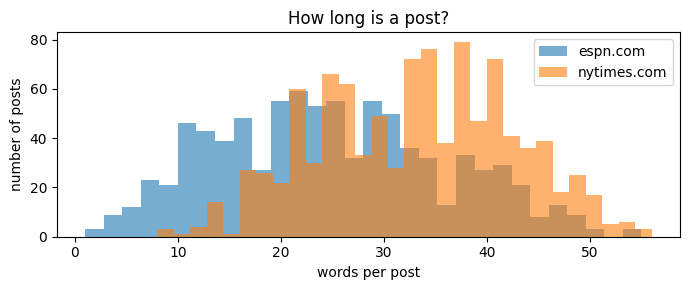

95% of posts have at most 47 words

espn.com: One more sleep until NFL football is BACK. 🏈
nytimes.com: In the 11 years since the last episode of "Glee" aired, "musical theater is less marginalized and pop is more 


In [8]:
lengths = []
for text in texts:
    lengths.append(len(text.split()))
lengths = np.asarray(lengths)

plt.figure(figsize=(7, 3))
for label, handle in enumerate(class_names):
    plt.hist(lengths[labels == label], bins=30, alpha=0.6, label=handle)
plt.xlabel("words per post")
plt.ylabel("number of posts")
plt.title("How long is a post?")
plt.legend()
plt.tight_layout()
plt.show()

print("95% of posts have at most", int(np.percentile(lengths, 95)), "words")
print()
for label, handle in enumerate(class_names):
    first = np.where(labels == label)[0][0]
    print(f"{handle}: {texts[first][:110]}")

## Split first, then tokenize

Same rule as every scaler this semester: **fit on TRAIN, apply to TEST.** The tokenizer builds its vocabulary from
the training posts only - if it saw the test posts, a word that only ever appears in test would sneak into the model.

In [9]:
X_train_text, X_test_text, y_train, y_test = train_test_split(
    texts, labels, test_size=0.2, random_state=5509, stratify=labels)

max_words = 5000      # keep the 5,000 most common words
maxlen = 50           # 95% of posts are shorter than this - pad or cut every post to 50 words

tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(X_train_text)             # learn the vocabulary from TRAIN only

X_train = pad_sequences(tokenizer.texts_to_sequences(X_train_text), maxlen=maxlen)
X_test = pad_sequences(tokenizer.texts_to_sequences(X_test_text), maxlen=maxlen)

print("unique words in the training posts:", len(tokenizer.word_index))
print("X_train:", X_train.shape, "   X_test:", X_test.shape)
print()
print("one post, before and after:")
print(X_train_text[0])
print(X_train[0])

unique words in the training posts: 8707
X_train: (1485, 50)    X_test: (372, 50)

one post, before and after:
"Nothing about softball scares me."

How drug cartel wars led coach Gerry Glasco to Texas Tech:
[   0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0  953   49 2454 3814  495   60 1139 3815
 2455  561   82 3816 3817    3  411  710]


## One helper to score every model

In [10]:
scores = {}          # weighted F1
macro = {}           # macro F1 - the score that notices the smaller class

def show_results(name, model):
    """Score a model on train and test with macro F1, then show the confusion matrix and report."""
    p_tr = model.predict(X_train, verbose=0).ravel()
    p_te = model.predict(X_test, verbose=0).ravel()
    pred_tr = (p_tr >= 0.5).astype(int)
    pred = (p_te >= 0.5).astype(int)
    scores[name] = f1_score(y_test, pred, average="weighted")
    macro[name] = f1_score(y_test, pred, average="macro")

    print(name)
    print(f"train  MACRO F1: {f1_score(y_train, pred_tr, average='macro'):.3f}"
          f"     weighted F1: {f1_score(y_train, pred_tr, average='weighted'):.3f}")
    print(f"TEST   MACRO F1: {macro[name]:.3f}"
          f"     weighted F1: {scores[name]:.3f}    <- MACRO is what we compare models on")
    print(confusion_matrix(y_test, pred))
    print(classification_report(y_test, pred, target_names=class_names, digits=3))

## Baseline: always guess the bigger account

Any model has to beat this, or it isn't learning anything.

In [11]:
majority = int(round(y_train.mean()))
maj_test = np.full(len(y_test), majority)

print(f"the bigger account in TRAIN is {class_names[majority]} ({100 * max(y_train.mean(), 1 - y_train.mean()):.1f}% of posts)")
print(f"always guess {class_names[majority]}:  accuracy = {accuracy_score(y_test, maj_test):.3f}"
      f"   weighted F1 = {f1_score(y_test, maj_test, average='weighted'):.3f}"
      f"   MACRO F1 = {f1_score(y_test, maj_test, average='macro'):.3f}")
scores["baseline: always the bigger account"] = f1_score(y_test, maj_test, average="weighted")
macro["baseline: always the bigger account"] = f1_score(y_test, maj_test, average="macro")

the bigger account in TRAIN is nytimes.com (53.9% of posts)
always guess nytimes.com:  accuracy = 0.538   weighted F1 = 0.376   MACRO F1 = 0.350


🔴
<!-- 🎙 DAVE TALKING POINTS — M5 · 12 — Capstone Pt 2: 100 posts vs all of them, macro F1, who wrote this?
- The monster is the IMDB monster from M5_2b_Understanding_RNNs, unchanged; it's a function because the ONLY thing that changes is how much data it gets. Same test set for both rounds.
- 100 posts per account: TEST MACRO F1 .854 (54 wrong out of 372). This pair is easy, so it isn't stuck at 50% like Gates vs Musk was.
- Every post: TEST MACRO F1 .938 (23 wrong). Ten times the data cut the errors in half.
- Who wrote this: Yankees, LeBron -> ESPN, dementia study -> Times... and the Senate sentence -> ESPN at P = 0.00. Pause on that.
- The shortcut: ESPN posts are shorter and padding puts zeros in FRONT, so the zero count tells the model the length. Times posts cut to 10 words: recognized 35% of the time vs 92% at full length.
- Add one more sentence to the Senate post and it flips to the Times at 0.99. Your model is only as honest as your data - go find the shortcut before your boss does.
- Hand off to the NPR exercise: same topics as the Times, different voice - the genuinely hard pair.
-->

## The monster, again

The same architecture as the end of the last notebook - embedding, a convolution and pooling to pull out short
phrases, a bidirectional LSTM, a GRU, and one sigmoid unit. We wrap it in a function because the **only** thing
that changes between the next two fits is how much data it gets.

In [12]:
def build_monster():
    """Embedding -> Conv1D -> pooling -> bidirectional LSTM -> GRU -> sigmoid. Same as the IMDB monster."""
    model = Sequential()
    model.add(Input(shape=(maxlen,)))
    model.add(Embedding(max_words, 128))                   # 5,000 words, 128 dimensions each
    model.add(Conv1D(filters=64, kernel_size=3))           # short phrases, three words at a time
    model.add(MaxPooling1D(2))
    model.add(Bidirectional(LSTM(30,
                                 return_sequences=True,    # stacking, so return the whole sequence
                                 activation="relu",
                                 recurrent_dropout=0.2)))
    model.add(GRU(20, activation="relu"))
    model.add(Dropout(0.1))
    model.add(Dense(1, activation="sigmoid"))
    model.compile(optimizer="rmsprop", loss="binary_crossentropy", metrics=["acc"])
    return model

build_monster().summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 50, 128)        │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 48, 64)         │        24,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 24, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 24, 60)         │        22,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 20)             │         4,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 20)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            21 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 692,381 (2.64 MB)

 Trainable params: 692,381 (2.64 MB)

 Non-trainable params: 0 (0.00 B)

## Round 1: only 100 posts per account

We keep the **same test set** for both rounds, so the only thing that changes is the size of the training data.

In [13]:
SMALL = 100                                      # posts per account

rng = np.random.default_rng(5509)
idx_small = []
for label in range(len(class_names)):
    rows = np.where(y_train == label)[0]
    chosen = rng.choice(rows, size=SMALL, replace=False)
    for r in chosen:
        idx_small.append(r)
idx_small = np.asarray(idx_small)

X_small = X_train[idx_small]
y_small = y_train[idx_small]
print("round 1 trains on", X_small.shape[0], "posts")

round 1 trains on 200 posts


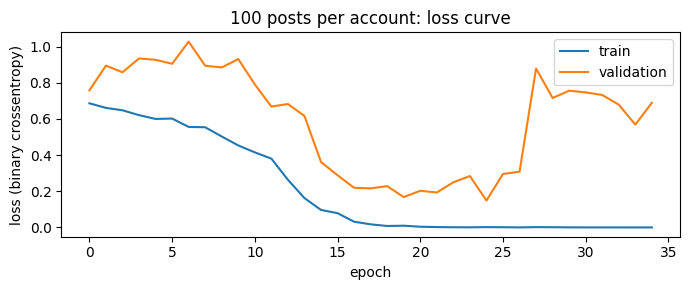

stopped after 35 epochs; best validation loss 0.149


In [14]:
keras.utils.set_random_seed(5509)                # re-seed before EVERY model build
model_small = build_monster()

es = EarlyStopping(monitor="val_loss", patience=10, start_from_epoch=10, restore_best_weights=True)

history = model_small.fit(X_small, y_small,
                          epochs=200,
                          batch_size=32,
                          validation_split=0.2,
                          callbacks=[es],
                          verbose=0)

# the loss curve - always keep the History object that fit() hands back
plt.figure(figsize=(7, 3))
plt.plot(history.history["loss"], label="train")
plt.plot(history.history["val_loss"], label="validation")
plt.xlabel("epoch")
plt.ylabel("loss (binary crossentropy)")
plt.title("100 posts per account: loss curve")
plt.legend()
plt.tight_layout()
plt.show()

print(f"stopped after {len(history.history['loss'])} epochs;"
      f" best validation loss {min(history.history['val_loss']):.3f}")

In [15]:
show_results("monster, 100 posts per account", model_small)

monster, 100 posts per account
train  MACRO F1: 0.880     weighted F1: 0.881
TEST   MACRO F1: 0.854     weighted F1: 0.855    <- MACRO is what we compare models on
[[150  22]
 [ 32 168]]
              precision    recall  f1-score   support

    espn.com      0.824     0.872     0.847       172
 nytimes.com      0.884     0.840     0.862       200

    accuracy                          0.855       372
   macro avg      0.854     0.856     0.854       372
weighted avg      0.856     0.855     0.855       372



## Round 2: every post we have

Same model, same seed, same test set. Only the amount of training data changes.

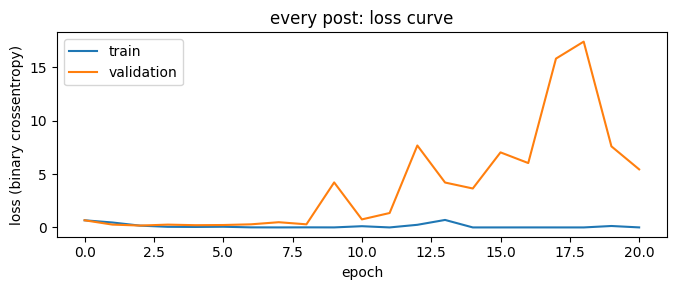

stopped after 21 epochs; best validation loss 0.174


In [16]:
keras.utils.set_random_seed(5509)                # re-seed before EVERY model build
model = build_monster()

es = EarlyStopping(monitor="val_loss", patience=10, start_from_epoch=10, restore_best_weights=True)

history = model.fit(X_train, y_train,
                    epochs=200,
                    batch_size=32,
                    validation_split=0.2,
                    callbacks=[es],
                    verbose=0)

# the loss curve - always keep the History object that fit() hands back
plt.figure(figsize=(7, 3))
plt.plot(history.history["loss"], label="train")
plt.plot(history.history["val_loss"], label="validation")
plt.xlabel("epoch")
plt.ylabel("loss (binary crossentropy)")
plt.title("every post: loss curve")
plt.legend()
plt.tight_layout()
plt.show()

print(f"stopped after {len(history.history['loss'])} epochs;"
      f" best validation loss {min(history.history['val_loss']):.3f}")

In [17]:
show_results("monster, every post", model)

monster, every post
train  MACRO F1: 0.986     weighted F1: 0.987
TEST   MACRO F1: 0.938     weighted F1: 0.938    <- MACRO is what we compare models on
[[164   8]
 [ 15 185]]
              precision    recall  f1-score   support

    espn.com      0.916     0.953     0.934       172
 nytimes.com      0.959     0.925     0.941       200

    accuracy                          0.938       372
   macro avg      0.937     0.939     0.938       372
weighted avg      0.939     0.938     0.938       372



## What the monster sees: two posts, as sequences
Each post is a sequence of word numbers (padded to 50), and the Embedding layer turns every word into 128 numbers it **learned** while training - its own home-made GloVe. One ESPN post and one NYT post, word by word:

In [ ]:
picks = [int(np.argmax(y_test == 0)), int(np.argmax(y_test == 1))]     # the first ESPN and the first NYT test post
fig, axes = plt.subplots(2, 1, figsize=(15, 8))
for a, k in enumerate(picks):
    row = X_test[k]
    words = []
    keep = []
    for slot in range(maxlen):
        if row[slot] != 0:                     # skip the padding at the front
            keep.append(slot)
            words.append(tokenizer.index_word.get(int(row[slot]), '?'))
    vectors = model.layers[0](row.reshape(1, -1)).numpy()[0]      # 50 words x 128 learned numbers
    print(class_names[y_test[k]], '|', X_test_text[k][:120])
    print('   as numbers:', row[keep])
    axes[a].imshow(vectors[keep].T, aspect='auto', cmap='coolwarm')
    axes[a].set_xticks(range(len(keep)))
    axes[a].set_xticklabels(words, rotation=60)
    axes[a].set_ylabel('learned number (1-128)')
    axes[a].set_title(class_names[y_test[k]] + ' post: one column of 128 numbers per word, read left to right')
plt.tight_layout()
plt.show()
# the LSTM and GRU read these columns one at a time, left to right - that's the sequence

## Save the model and use it again

In [18]:
from keras.models import load_model

model.save("who_posted_it.keras")                # one file: architecture + weights + optimizer state
reloaded = load_model("who_posted_it.keras")

same = np.allclose(model.predict(X_test[:5], verbose=0), reloaded.predict(X_test[:5], verbose=0))
print("reloaded model reproduces the predictions:", same)

reloaded model reproduces the predictions: True


## Who wrote this?

Type any sentence you like. It goes through the **same tokenizer** (fit on the training posts) and the same
padding, then into the reloaded model.

In [19]:
new_posts = [
    "The Yankees clinched the division with a walk-off homer in the ninth.",
    "The Senate passed the spending bill after a late-night vote.",
    "LeBron James says he is not thinking about retirement yet.",
    "A new study links air pollution to a higher risk of dementia.",
]

seqs = pad_sequences(tokenizer.texts_to_sequences(new_posts), maxlen=maxlen)
probs = reloaded.predict(seqs, verbose=0).ravel()
for text, p in zip(new_posts, probs):
    guess = class_names[int(p >= 0.5)]
    print(f"{guess:12s} (P[{class_names[1]}] = {p:.2f})  {text}")

espn.com     (P[nytimes.com] = 0.00)  The Yankees clinched the division with a walk-off homer in the ninth.
espn.com     (P[nytimes.com] = 0.00)  The Senate passed the spending bill after a late-night vote.
espn.com     (P[nytimes.com] = 0.00)  LeBron James says he is not thinking about retirement yet.
nytimes.com  (P[nytimes.com] = 0.81)  A new study links air pollution to a higher risk of dementia.


## What is it really looking at?

Look at the Senate sentence. That is a New York Times sentence if there ever was one - and the model says ESPN.

Here's a clue: **ESPN's posts are shorter.** And remember what padding does - it adds zeros to the *front* of
every short post. So the number of zeros quietly tells the model how long the post is. Did it learn *what* each
account writes about... or just *how much* each account writes? Let's test it: cut every Times post in the test
set down to its first 10 words and see if the model still recognizes them.

In [20]:
nyt_rows = np.where(y_test == 1)[0]

full_text = []
short_text = []
for r in nyt_rows:
    full_text.append(X_test_text[r])
    words = X_test_text[r].split()
    short_text.append(" ".join(words[:10]))       # the first 10 words only

p_full = model.predict(pad_sequences(tokenizer.texts_to_sequences(full_text), maxlen=maxlen), verbose=0).ravel()
p_short = model.predict(pad_sequences(tokenizer.texts_to_sequences(short_text), maxlen=maxlen), verbose=0).ravel()

print(f"Times test posts, full length:     called the Times {np.mean(p_full >= 0.5):.0%} of the time")
print(f"the same posts, first 10 words:    called the Times {np.mean(p_short >= 0.5):.0%} of the time")
print()

senate = "The Senate passed the spending bill after a late-night vote."
for text in [senate, senate + " Here's what's in it and what it means for you."]:
    seq = pad_sequences(tokenizer.texts_to_sequences([text]), maxlen=maxlen)
    p = reloaded.predict(seq, verbose=0).ravel()[0]
    print(f"P[{class_names[1]}] = {p:.2f}   ({len(text.split())} words)  {text}")

Times test posts, full length:     called the Times 92% of the time
the same posts, first 10 words:    called the Times 35% of the time



P[nytimes.com] = 0.00   (10 words)  The Senate passed the spending bill after a late-night vote.


P[nytimes.com] = 0.99   (20 words)  The Senate passed the spending bill after a late-night vote. Here's what's in it and what it means for you.


The model partly learned **how long** each account writes, not just **what** it writes about. That's called a
**shortcut**: it works on this data, and it fails the moment someone writes a short post in the Times' style.
Your model is only as honest as your data - so when a result looks great, go looking for the shortcut before
your boss does.

## The scoreboard

In [21]:
board = pd.DataFrame({"weighted F1": pd.Series(scores), "MACRO F1": pd.Series(macro)})
board.sort_values("MACRO F1", ascending=False).round(3)

,weighted F1,MACRO F1
"monster, every post",0.938,0.938
"monster, 100 posts per account",0.855,0.854
baseline: always the bigger account,0.376,0.350


## Your turn: swap ESPN for NPR

Change one line in the settings cell:

```python
ACCOUNTS = ["npr.org", "nytimes.com"]
```

and **Run all**. The snapshot already has 1,000 NPR posts. Then answer:

1. Before you run it - do you expect NPR vs the Times to be **easier or harder** than ESPN vs the Times? Why?
2. What happens to MACRO F1 with 100 posts per account, and with all of them?
3. Look at the posts your model gets wrong. Would *you* have gotten them right?
4. Run the "What is it really looking at?" cell. Is post length still a shortcut? (Hint: are NPR's posts shorter
   or longer than the Times'?)
5. Set `USE_SNAPSHOT = False` and model a fresh pull. Do your numbers move? Why might they?

## Terminology

* **Bag of words** - text as word counts; word order is thrown away (Module 5.1).
* **Sequence** - text as words in order; the model reads them one step at a time (Module 5.2).
* **Token** - one unit the tokenizer keeps; here, a word.
* **Padding** - adding zeros (or cutting words) so every post has the same length, `maxlen`.
* **Embedding** - a learned vector for each word; similar words end up close together.
* **Cursor** - the API's bookmark for "the next page of posts."
* **Repost** - an account sharing someone else's post; skipped here, because it isn't the account's own words.
* **Macro F1** - the F1 of each class, averaged with equal weight, so a smaller class can't hide.
* **Shortcut** - a pattern that predicts the label in your data for the wrong reason (here: post length).